# Ejercicio 4 — Aprendizaje Profundo
## Clasificación de residuos para reciclaje (CNN desde cero vs Transfer Learning)

Este notebook es la **capa narrativa** del entregable: cada celda es una llamada a
`pipeline/` más su explicación, sin lógica de negocio (la lógica vive en los
módulos). Sirve además como entorno de ejecución en **Google Colab con GPU**.

**Problema y motivación.** Se clasifican imágenes de residuos en 5 categorías
(`cardboard`, `glass`, `metal`, `paper`, `plastic`) para apoyar la separación
automática en reciclaje. Es un problema de **clasificación** (no detección): cada
imagen pertenece a una sola clase.

**Dataset.** TrashNet (garythung/trashnet, Stanford), versión redimensionada
512×384, descargada desde GitHub sin autenticación. Se usan 5 de las 6 clases
(se descarta `trash`), cada una recortada a 400 imágenes → 2000 balanceadas.

## 0. Entorno (Colab con GPU / local)

In [1]:
# Funciona en Google Colab (clona el repo + instala deps) y en local (ya en el repo).
import os, sys, subprocess

EN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Gonzalo-Romero-V/EJML---04-Aprendizaje-Profundo.git"
REPO_DIR = REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")

if EN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "requirements.txt"], check=True)

import tensorflow as tf
print("TensorFlow", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


> En Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)**
> antes de ejecutar. Si la lista de GPU sale vacía, el entrenamiento correrá en CPU
> (mucho más lento).

## Parte A — Dataset

Descarga el zip de TrashNet, selecciona las 5 clases, recorta a 400 por clase y
arma `data/dataset/<clase>/`. El código de descarga es parte del entregable.

In [2]:
!python scripts/preparar_dataset.py

[Parte A] Preparacion del dataset de residuos (TrashNet)
  · zip ya presente (42.8 MB), se omite descarga
  · ya descomprimido en data/raw/dataset-resized, se omite

  Dataset final (data/dataset/<clase>/):
      cardboard  400 imagenes
      glass      400 imagenes
      metal      400 imagenes
      paper      400 imagenes
      plastic    400 imagenes
      TOTAL      2000 imagenes en 5 clases
  Balance: min=400, max=400  (ratio mayoritaria 20% — limite 60/40)

✓ Listo. Cargar con image_dataset_from_directory sobre data/dataset


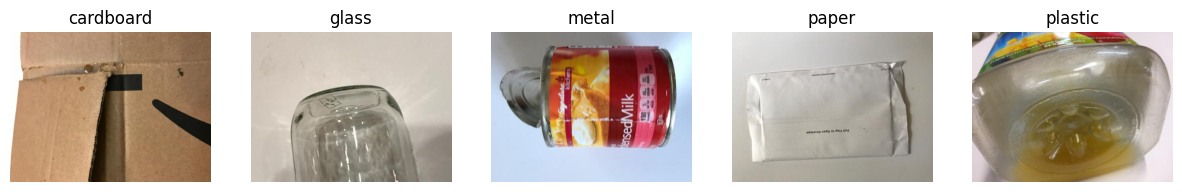

In [3]:
# Una imagen de muestra por clase (verificación visual del dataset).
import matplotlib.pyplot as plt
from PIL import Image
from pipeline import config

fig, axes = plt.subplots(1, len(config.CLASES), figsize=(15, 3))
for ax, clase in zip(axes, config.CLASES):
    muestra = next((config.DATASET_DIR / clase).iterdir())
    ax.imshow(Image.open(muestra)); ax.set_title(clase); ax.axis("off")
plt.show()

## Parte B — CNN desde cero

Se carga el dataset con split 80/20 y **data augmentation solo en train** (flip,
rotación, zoom). La normalización (Rescaling 1/255) va dentro del modelo.

In [4]:
"""Si da un error en esta parte lo mas probable es por cruce de versiones
entre Numpy que trae por defecto el entorno y Numpy de Requirements.txt
Si sucede, es necesario entrar en Entorno de Ejecucion -> Reiniciar (o incluso interrumpir) y
volver a ejecutar desde el inicio"""
import time
import numpy as np
import pandas as pd
from IPython.display import Image as Img
from pipeline import data, cnn, transfer, evaluation as ev, audit, plotting

tr, va, clases = data.cargar_datasets()
test_ds, _ = data.cargar_test_crudo()
print("clases:", clases)

Found 2000 files belonging to 5 classes.
Using 1600 files for training.
Found 2000 files belonging to 5 classes.
Using 400 files for validation.
Found 2000 files belonging to 5 classes.
Using 400 files for validation.
clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


**Arquitectura.** 3 bloques convolucionales (Conv-BN-Conv-BN-MaxPool-Dropout) con
32, 64 y 128 filtros (se duplican al reducir resolución para representar patrones
cada vez más compuestos), kernel 3×3, BatchNormalization (estabiliza el
entrenamiento) y Dropout 0.25 (regulariza). La cabeza usa Global Average Pooling
(menos parámetros y menos sobreajuste que Flatten), una densa de 128, Dropout 0.5
y softmax de 5 clases.

In [5]:
modelo_cnn = cnn.construir_cnn()
modelo_cnn.summary()

Model: "cnn_propia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ultimo_conv (Conv2D)            │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_densa (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_cabeza (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 5)              │           64

 Total params: 306,469 (1.17 MB)

 Trainable params: 305,317 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/40
50/50 - 36s - 729ms/step - accuracy: 0.4356 - loss: 1.6566 - val_accuracy: 0.4500 - val_loss: 1.3980
Epoch 2/40
50/50 - 5s - 107ms/step - accuracy: 0.4919 - loss: 1.3706 - val_accuracy: 0.4950 - val_loss: 1.3635
Epoch 3/40
50/50 - 8s - 152ms/step - accuracy: 0.5419 - loss: 1.2470 - val_accuracy: 0.6000 - val_loss: 1.1509
Epoch 4/40
50/50 - 6s - 114ms/step - accuracy: 0.5944 - loss: 1.0491 - val_accuracy: 0.4875 - val_loss: 1.7637
Epoch 5/40
50/50 - 7s - 137ms/step - accuracy: 0.6050 - loss: 1.0466 - val_accuracy: 0.4800 - val_loss: 1.9225
Epoch 6/40
50/50 - 6s - 119ms/step - accuracy: 0.6425 - loss: 0.9527 - val_accuracy: 0.4875 - val_loss: 1.8951
Epoch 7/40
50/50 - 7s - 150ms/step - accuracy: 0.6650 - loss: 0.8832 - val_accuracy: 0.3275 - val_loss: 2.8451
Epoch 8/40
50/50 - 8s - 168ms/step - accuracy: 0.6681 - loss: 0.8597 - val_accuracy: 0.5400 - val_loss: 1.4226


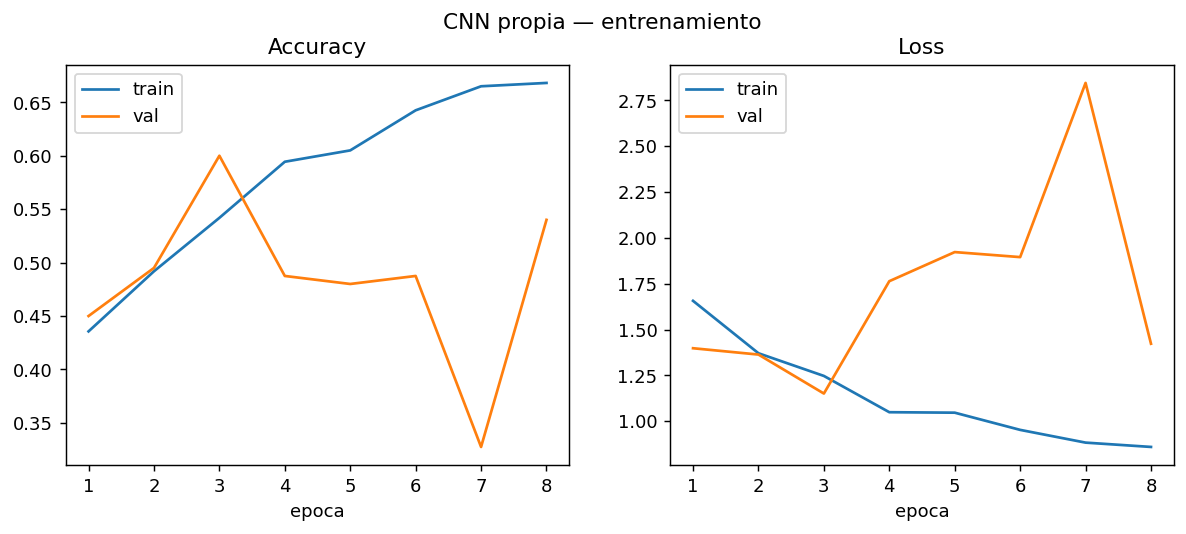

In [6]:
t0 = time.time()
hist_cnn = modelo_cnn.fit(tr, validation_data=va, epochs=config.CNN_EPOCHS,
                          callbacks=cnn.callbacks_entrenamiento(), verbose=2)
t_cnn = time.time() - t0
Img(str(plotting.curvas_entrenamiento(hist_cnn.history, "cnn_curvas.png",
                                      "CNN propia — entrenamiento")))

,precision,recall,f1-score,support
cardboard,0.860,0.690,0.766,71.0
glass,0.625,0.390,0.480,77.0
metal,0.461,0.455,0.458,77.0
paper,0.481,0.882,0.622,85.0
plastic,0.810,0.567,0.667,90.0
accuracy,0.600,0.600,0.600,0.6
macro avg,0.647,0.597,0.598,400.0
weighted avg,0.646,0.600,0.599,400.0


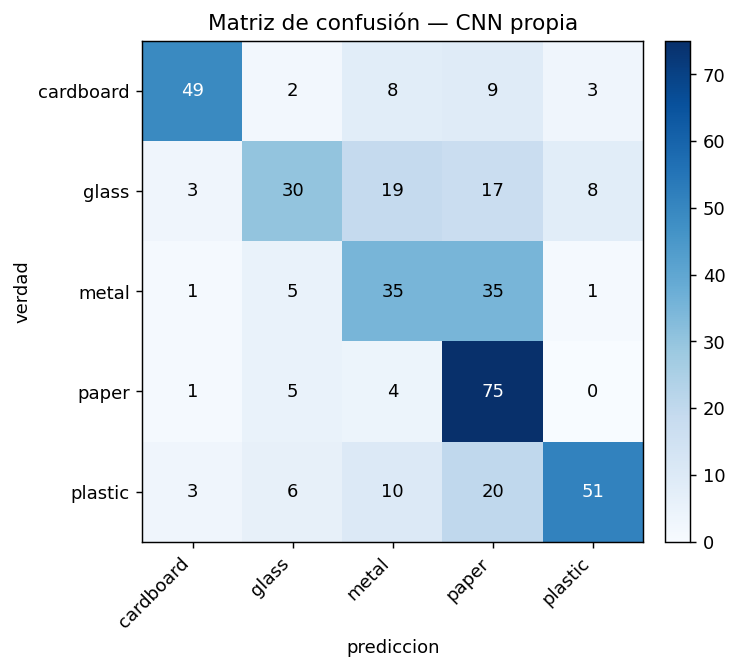

In [7]:
# Métricas por clase y matriz de confusión sobre el test.
yt, yp, _ = ev.predecir(modelo_cnn, test_ds)
rep_cnn = ev.reporte_clasificacion(yt, yp, clases)
display(pd.DataFrame(rep_cnn).T.round(3))
cm_cnn = ev.matriz_confusion(yt, yp, len(clases))
Img(str(plotting.matriz_confusion_fig(cm_cnn, clases, "confusion_cnn.png",
                                      "Matriz de confusión — CNN propia")))

**Grad-CAM.** Resalta las zonas de la imagen que la red usa para decidir. Si el
mapa se enciende sobre el objeto (no sobre el fondo), la red aprendió patrones
reales. Se muestran 3 imágenes de test bien clasificadas.

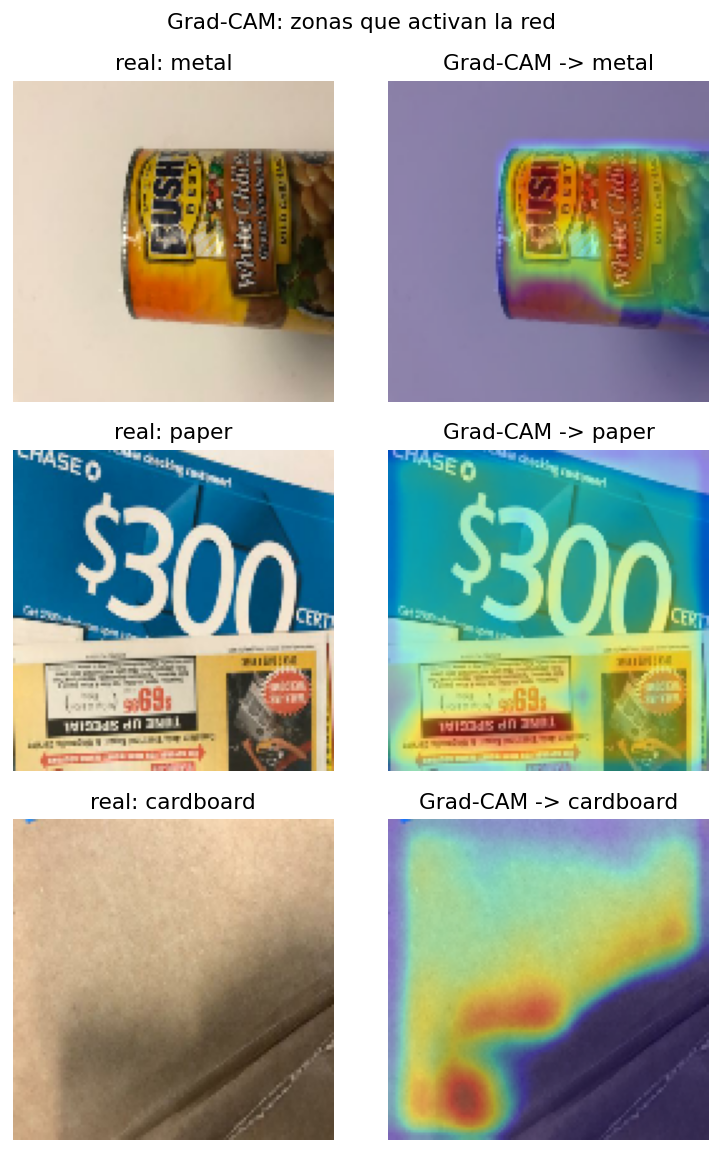

In [8]:
imgs, ytg, ypg = audit.recolectar_predicciones(modelo_cnn, test_ds)
sel = np.flatnonzero(ytg == ypg)[:3]
Img(str(plotting.grid_gradcam(modelo_cnn, imgs[sel], clases, ytg[sel], ypg[sel],
                              "gradcam_cnn.png")))

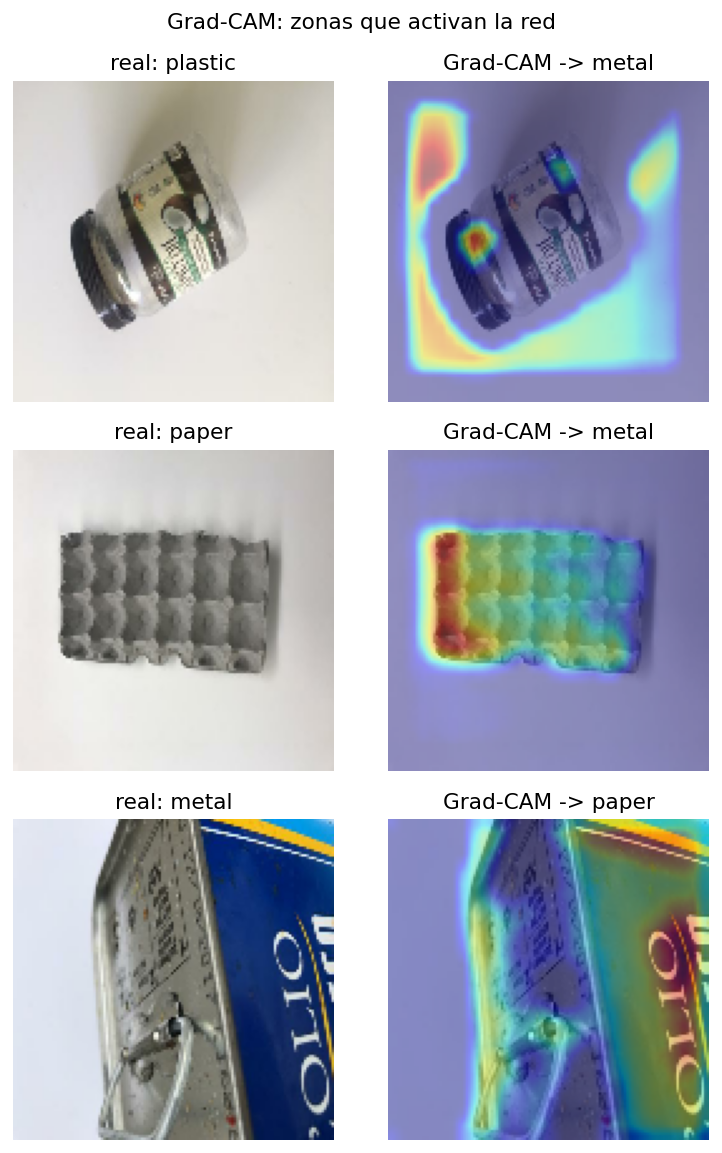

In [22]:
# Grad-CAM sobre ERRORES (pregunta técnica 13: zona activada en una predicción INCORRECTA)
err = np.flatnonzero(ytg != ypg)[:3]   # ytg != ypg  →  fallos
Img(str(plotting.grid_gradcam(modelo_cnn, imgs[err], clases, ytg[err], ypg[err],
                              "gradcam_cnn_errores.png")))

## Parte C — Transfer Learning con MobileNetV2

**Fase 1 (Feature Extraction):** base congelada, se entrena solo la cabeza nueva
(lr alto 1e-3). **Fase 2 (Fine-Tuning):** se descongelan las últimas 30 capas con
lr muy bajo (1e-5) para ajustar sin destruir los pesos preentrenados.

In [9]:
modelo_tl, base = transfer.construir_transfer()
transfer.compilar_fase1(modelo_tl)
print("Params entrenables Fase 1:", ev.params_entrenables(modelo_tl))
t0 = time.time()
h1 = modelo_tl.fit(tr, validation_data=va, epochs=config.TL_FE_EPOCHS,
                   callbacks=transfer.callbacks_entrenamiento(), verbose=2)
t_f1 = time.time() - t0
yt1, yp1, _ = ev.predecir(modelo_tl, test_ds)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Params entrenables Fase 1: 6405
Epoch 1/10
50/50 - 54s - 1s/step - accuracy: 0.4913 - loss: 1.2861 - val_accuracy: 0.7325 - val_loss: 0.7557
Epoch 2/10
50/50 - 5s - 92ms/step - accuracy: 0.6963 - loss: 0.7789 - val_accuracy: 0.7750 - val_loss: 0.6219
Epoch 3/10
50/50 - 6s - 120ms/step - accuracy: 0.7644 - loss: 0.6289 - val_accuracy: 0.8125 - val_loss: 0.5594
Epoch 4/10
50/50 - 5s - 92ms/step - accuracy: 0.7800 - loss: 0.5917 - val_accuracy: 0.8075 - val_loss: 0.5429
Epoch 5/10
50/50 - 6s - 115ms/step - accuracy: 0.8012 - loss: 0.5141 - val_accuracy: 0.8250 - val_loss: 0.4974
Epoch 6/10
50/50 - 5s - 90ms/step - accuracy: 0.8269 - loss: 0.4737 - val_accuracy: 0.8250 - val_loss: 0.4998
Epoch 7/10
50/50 - 7s - 133ms/step - accuracy: 0.8219 - loss: 0.4721 - val_accuracy: 0.8125 - val_loss: 0.4915
Epoch 8/10
50/50 - 5s - 100ms/step - accuracy: 0.8350 - loss: 0.4395 - val_accuracy: 0.8325 - val_loss: 0.4889
Epoch 9/10
50/50 - 5s - 91ms/step - 

Params entrenables Fase 2: 1517125
Epoch 1/10
50/50 - 28s - 556ms/step - accuracy: 0.8487 - loss: 0.4178 - val_accuracy: 0.8250 - val_loss: 0.4906
Epoch 2/10
50/50 - 5s - 95ms/step - accuracy: 0.8706 - loss: 0.3575 - val_accuracy: 0.8350 - val_loss: 0.4677
Epoch 3/10
50/50 - 5s - 104ms/step - accuracy: 0.8781 - loss: 0.3219 - val_accuracy: 0.8375 - val_loss: 0.4300
Epoch 4/10
50/50 - 5s - 108ms/step - accuracy: 0.8931 - loss: 0.2971 - val_accuracy: 0.8450 - val_loss: 0.4600
Epoch 5/10
50/50 - 5s - 91ms/step - accuracy: 0.8875 - loss: 0.2933 - val_accuracy: 0.8500 - val_loss: 0.4483
Epoch 6/10
50/50 - 6s - 115ms/step - accuracy: 0.8869 - loss: 0.2867 - val_accuracy: 0.8400 - val_loss: 0.4422
Epoch 7/10
50/50 - 9s - 181ms/step - accuracy: 0.9038 - loss: 0.2656 - val_accuracy: 0.8475 - val_loss: 0.4531
Epoch 8/10
50/50 - 6s - 116ms/step - accuracy: 0.9144 - loss: 0.2480 - val_accuracy: 0.8525 - val_loss: 0.4428


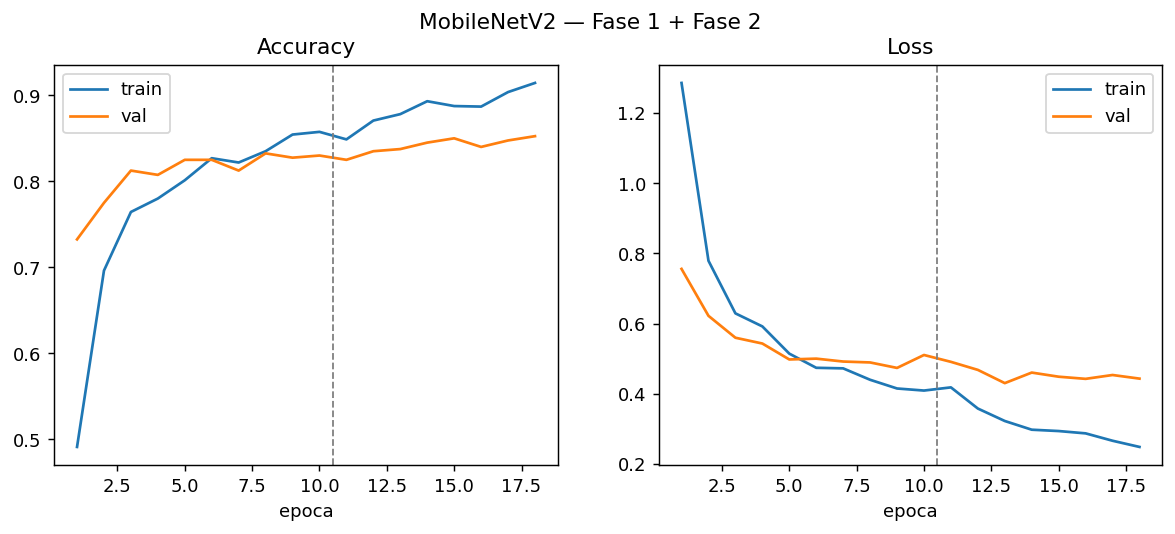

In [10]:
transfer.preparar_fase2(modelo_tl, base)
print("Params entrenables Fase 2:", ev.params_entrenables(modelo_tl))
t0 = time.time()
h2 = modelo_tl.fit(tr, validation_data=va, epochs=config.TL_FT_EPOCHS,
                   callbacks=transfer.callbacks_entrenamiento(), verbose=2)
t_f2 = time.time() - t0
yt2, yp2, _ = ev.predecir(modelo_tl, test_ds)
hist_tl = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}
Img(str(plotting.curvas_entrenamiento(hist_tl, "tl_curvas.png",
        "MobileNetV2 — Fase 1 + Fase 2",
        linea_finetuning=len(h1.history["accuracy"]))))

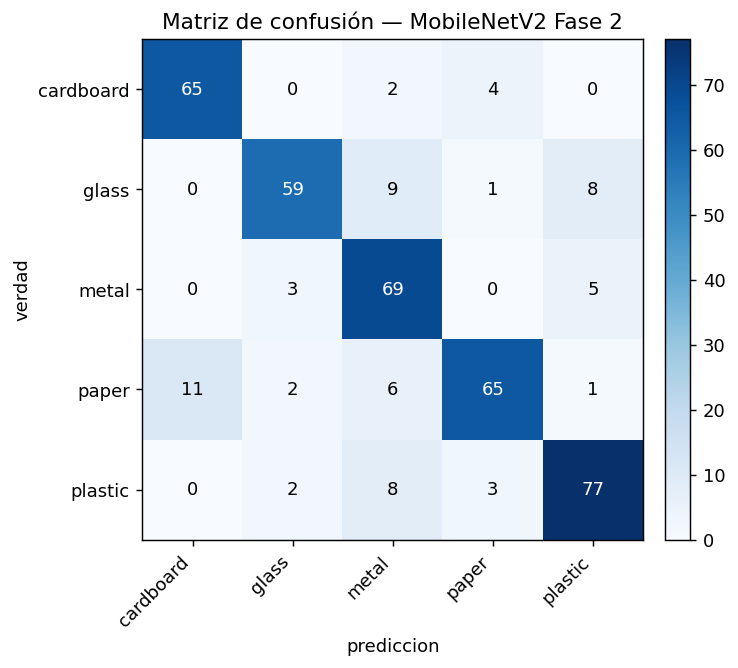

In [11]:
cm_tl = ev.matriz_confusion(yt2, yp2, len(clases))
Img(str(plotting.matriz_confusion_fig(cm_tl, clases, "confusion_tl.png",
                                      "Matriz de confusión — MobileNetV2 Fase 2")))

**Tabla comparativa de los 3 modelos.** Nota la diferencia de parámetros
entrenables: MobileNetV2 Fase 1 logra buen accuracy ajustando muy pocos
parámetros, porque reutiliza las características aprendidas en ImageNet.

,modelo,accuracy,f1_macro,tiempo_entren_s,params_entrenables
0,CNN propia,0.6000,0.598443,88.5,305317
1,MobileNetV2 Fase 1,0.8275,0.827522,105.9,1517125
2,MobileNetV2 Fase 2,0.8375,0.838032,68.4,1517125


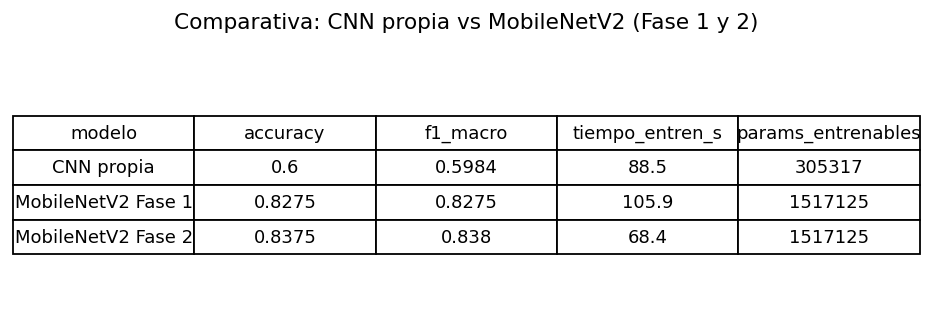

In [12]:
filas = [
    ev.fila_comparativa("CNN propia", yt, yp, tiempo_s=t_cnn, modelo=modelo_cnn),
    ev.fila_comparativa("MobileNetV2 Fase 1", yt1, yp1, tiempo_s=t_f1, modelo=modelo_tl),
    ev.fila_comparativa("MobileNetV2 Fase 2", yt2, yp2, tiempo_s=t_f2, modelo=modelo_tl),
]
df = ev.tabla_comparativa(filas)
display(df)
Img(str(plotting.tabla_comparativa_fig(df, "tabla_comparativa.png")))

## Parte D — Auditoría y mejora

Análisis crítico de los propios modelos: par de clases más confundido, intento de
mejora del modelo más débil, e imágenes mal clasificadas por el mejor modelo.

In [15]:
ca, cb, n_conf = audit.par_mas_confundido(cm_cnn, clases)
print(f"Par más confundido por la CNN: {ca} <-> {cb} ({n_conf} casos)")

Par más confundido por la CNN: metal <-> paper (35 casos)


**Dos mejoras** sobre la CNN propia (el modelo de menor F1): regularización **L2**
(mejora 1) y un **schedule de learning rate** con ReduceLROnPlateau (mejora 2). Se
documenta honestamente si mejoraron o no.

In [16]:
f1_por_modelo = {f["modelo"]: f["f1_macro"] for f in filas}
peor = min(f1_por_modelo, key=f1_por_modelo.get)
print("Modelo con menor F1:", peor, round(f1_por_modelo[peor], 3))

modelo_mej = audit.construir_cnn_mejorada()
modelo_mej.fit(tr, validation_data=va, epochs=config.CNN_EPOCHS,
               callbacks=audit.callbacks_mejorados(), verbose=2)
ytm, ypm, _ = ev.predecir(modelo_mej, test_ds)
f1_mej = ev.reporte_clasificacion(ytm, ypm, clases)["macro avg"]["f1-score"]
f1_base = rep_cnn["macro avg"]["f1-score"]
print(f"F1 CNN base {f1_base:.3f} -> mejorada {f1_mej:.3f} "
      f"({'mejoró' if f1_mej > f1_base else 'no mejoró'})")

Modelo con menor F1: CNN propia 0.598
Epoch 1/40
50/50 - 21s - 427ms/step - accuracy: 0.4275 - loss: 1.6503 - val_accuracy: 0.2925 - val_loss: 2.0397 - learning_rate: 0.0010
Epoch 2/40
50/50 - 9s - 174ms/step - accuracy: 0.5150 - loss: 1.3664 - val_accuracy: 0.5100 - val_loss: 1.6435 - learning_rate: 0.0010
Epoch 3/40
50/50 - 6s - 120ms/step - accuracy: 0.5437 - loss: 1.2667 - val_accuracy: 0.5250 - val_loss: 1.3787 - learning_rate: 0.0010
Epoch 4/40
50/50 - 5s - 101ms/step - accuracy: 0.5750 - loss: 1.1575 - val_accuracy: 0.2950 - val_loss: 2.3267 - learning_rate: 0.0010
Epoch 5/40
50/50 - 6s - 122ms/step - accuracy: 0.6150 - loss: 1.0814 - val_accuracy: 0.3525 - val_loss: 1.9340 - learning_rate: 0.0010
Epoch 6/40
50/50 - 5s - 103ms/step - accuracy: 0.6094 - loss: 1.0509 - val_accuracy: 0.4775 - val_loss: 1.3922 - learning_rate: 0.0010
Epoch 7/40
50/50 - 6s - 124ms/step - accuracy: 0.6631 - loss: 0.9399 - val_accuracy: 0.5725 - val_loss: 1.2601 - learning_rate: 5.0000e-04
Epoch 8/40
5

Mejor modelo: MobileNetV2 Fase 2 | total mal clasificadas: 65


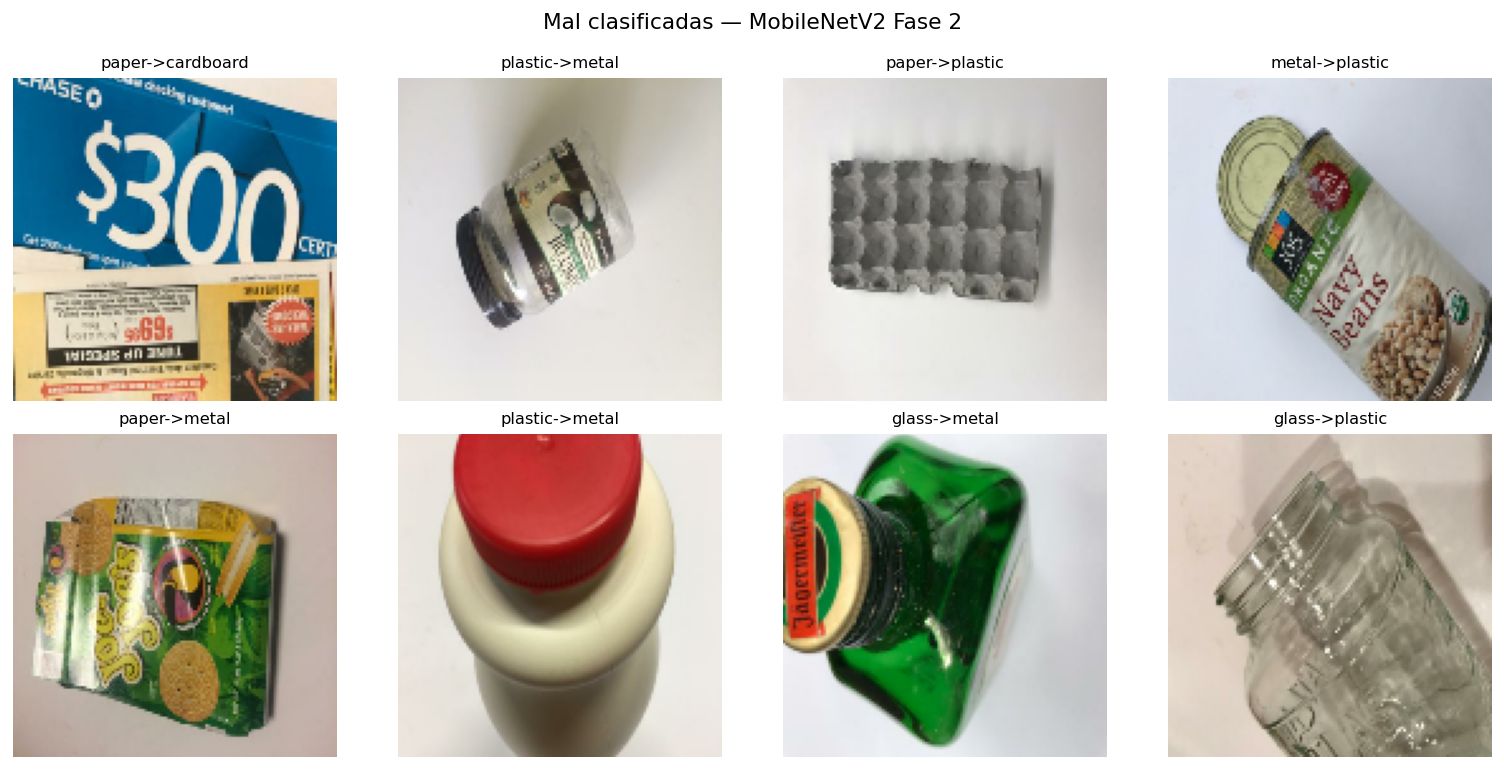

In [17]:
# Imágenes mal clasificadas por el mejor modelo global.
mejor = max(f1_por_modelo, key=f1_por_modelo.get)
usar = (modelo_cnn, yt, yp) if mejor == "CNN propia" else (modelo_tl, yt2, yp2)
imb, ytb, ypb = audit.recolectar_predicciones(usar[0], test_ds)
err = audit.indices_mal_clasificados(ytb, ypb, maximo=8)
titulos = [f"{clases[ytb[i]]}->{clases[ypb[i]]}" for i in err]
print(f"Mejor modelo: {mejor} | total mal clasificadas: {int((ytb != ypb).sum())}")
Img(str(plotting.grid_imagenes(imb[err], titulos, "errores_mejor_modelo.png",
                               f"Mal clasificadas — {mejor}")))

In [18]:
# Clase con menor Recall (pregunta técnica 18).
clase_r, recall_r = ev.clase_menor_recall(rep_cnn, clases)
print(f"Clase con menor Recall en la CNN: {clase_r} ({recall_r:.3f})")

Clase con menor Recall en la CNN: glass (0.390)
